# Exploratory Data Analysis (EDA)



Will the removal of level crossings and related transport improvements along the Upfield line drive faster house price growth in adjacent suburbs compared to those located away from the line?

Focusing on three main variables:
- Suburb
- House price
- Population density

## Visualisations

**Suburbs (new) with removed level crossings to closest LXRP site (km)**

In [44]:
import pandas as pd

suburbs = [
    ("Chelsea", 4),
    ("Laverton", 3),
    ("Ringwood", 2),
    ("Mentone", 2),
    ("Preston", 1),
    ("Blackburn", 2),
    ("Beaconsfield", 2),
    ("Essendon", 1),
    ("Glen Iris", 1),
    ("Cranbourne", 3),
    ("Campbellfield", 3),
    ("Pakenham", 3),
    ("Lilydale", 2),
    ("Bentleigh", 1),
    ("Clayton", 2),
    ("Noble Park", 2),
    ("Cheltenham", 2),
    ("Werribee", 3),
    ("Berwick", 3),
    ("Croydon", 0),
    ("Noble Park", 0),
    ("Edithvale", 2),
    ("Williamstown", 1),
    ("Ardeer", 1),
    ("St Albans", 1),
    ("Sunbury", 2),
    ("Glenroy", 0),
    ("Alphington", 1),
    ("Carnegie", 1),
    ("Hallam", 3),
    ("Mitcham", 2),
    ("Reservoir", 0),
    ("Coburg", 0),
    ("Brunswick", 0),
    ("Bundoora", 4),
    ("Doncaster", 10),
    ("Doncaster East", 12),
    ("Donvale", 9),
    ("Templestowe", 8),
    ("Templestowe Lower", 6),
    ("Warrandyte", 12),
    ("Wonga Park", 15),
    ("Park Orchards", 9),
    ("Bulleen", 10),
    ("Rowville", 10),
    ("Lysterfield", 11),
    ("Scoresby", 9),
    ("Knoxfield", 9),
    ("Wantirna", 6),
    ("Wantirna South", 7),
    ("The Basin", 7),
    ("Endeavour Hills", 6),
    ("Doveton", 4),
    ("Greenvale", 7),
    ("Gladstone Park", 6),
    ("Westmeadows", 3),
    ("Tullamarine", 6),
    ("Keilor East", 4),
]

suburb_table = pd.DataFrame(
    suburbs,
    columns=["Suburb", "nearest LXRP site"],
)
suburb_table = suburb_table.sort_values(
    by=["nearest LXRP site", "Suburb"],
    kind="mergesort",
).reset_index(drop=True)
display(suburb_table)

,Suburb,nearest LXRP site
0,Brunswick,0
1,Coburg,0
2,Croydon,0
3,Glenroy,0
4,Noble Park,0
5,Reservoir,0
6,Alphington,1
7,Ardeer,1
8,Bentleigh,1
9,Carnegie,1


**House prices for grouped suburbs (2015 to 2024)**

The suburbs will be separated into two groups, "Adjacent" and "Faraway" based on their distance to the closest LXRP site.

In [56]:
from pathlib import Path
import pandas as pd
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "data" / "clean").exists():
    project_root = project_root.parent

adjacent_path = project_root / "data" / "clean" / "adjacent_suburbs_house_prices_2015_2024.csv"
faraway_path = project_root / "data" / "clean" / "faraway_suburbs_house_prices_2015_2024.csv"

adjacent_df = pd.read_csv(adjacent_path)
faraway_df = pd.read_csv(faraway_path)

adjacent_suburbs = [
    "Chelsea", "Laverton", "Ringwood", "Mentone", "Preston", "Blackburn",
    "Beaconsfield", "Essendon", "Glen Iris", "Cranbourne", "Campbellfield",
    "Pakenham", "Lilydale", "Bentleigh", "Clayton", "Noble Park", "Cheltenham",
    "Werribee", "Berwick", "Croydon", "Noble Park", "Edithvale", "Williamstown",
    "Ardeer", "St Albans", "Sunbury", "Glenroy", "Alphington", "Carnegie",
    "Hallam", "Mitcham", "Reservoir", "Coburg", "Brunswick", "Bundoora",
]

faraway_suburbs = [
    "Doncaster", "Doncaster East", "Donvale", "Templestowe", "Templestowe Lower",
    "Warrandyte", "Wonga Park", "Park Orchards", "Bulleen", "Rowville",
    "Lysterfield", "Scoresby", "Knoxfield", "Wantirna", "Wantirna South",
    "The Basin", "Endeavour Hills", "Doveton", "Greenvale", "Gladstone Park",
    "Westmeadows", "Tullamarine", "Keilor East",
]

year_cols = [str(y) for y in range(2015, 2025)]
selected_cols = ["Suburb"] + year_cols

adjacent_table = (
    adjacent_df.set_index("Suburb")[year_cols]
    .reindex(adjacent_suburbs)
    .reset_index()[selected_cols]
)

faraway_table = (
    faraway_df.set_index("Suburb")[year_cols]
    .reindex(faraway_suburbs)
    .reset_index()[selected_cols]
)

print(f"Adjacent table rows: {len(adjacent_table)} | Unique suburbs: {adjacent_table['Suburb'].nunique()}")
display(adjacent_table)

print(f"Faraway table rows: {len(faraway_table)} | Unique suburbs: {faraway_table['Suburb'].nunique()}")
display(faraway_table)

Adjacent table rows: 35 | Unique suburbs: 34


,Suburb,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Chelsea,730000.0,890000.0,914000.0,905000.0,856500.0,980000.0,1167500.0,1140000.0,1180000.0,1210000.0
1,Laverton,377500.0,429000.0,535000.0,579000.0,529000.0,560000.0,605000.0,610000.0,582500.0,590000.0
2,Ringwood,777500.0,837500.0,910500.0,896500.0,801000.0,900000.0,1018000.0,1038000.0,999500.0,1025000.0
3,Mentone,950000.0,982500.0,1097500.0,1080000.0,1031000.0,1050000.0,1370000.0,1475000.0,1332500.0,1320000.0
4,Preston,791000.0,882000.0,996000.0,980000.0,940000.0,1026000.0,1250000.0,1136000.0,1145000.0,1185000.0
5,Blackburn,1200500.0,1241000.0,1410000.0,1370500.0,1305000.0,1405000.0,1639500.0,1549500.0,1569000.0,1517000.0
6,Beaconsfield,559000.0,585000.0,694500.0,730000.0,685000.0,711000.0,892000.0,940000.0,920000.0,990000.0
7,Essendon,1228000.0,1365000.0,1400000.0,1691000.0,1450000.0,1520000.0,1750000.0,1845500.0,1795000.0,1741500.0
8,Glen Iris,1800000.0,1935000.0,2025000.0,1927500.0,1967000.0,2136000.0,2492500.0,2500000.0,2500000.0,2370000.0
9,Cranbourne,360000.0,406000.0,510000.0,540000.0,500000.0,510000.0,618000.0,660000.0,655000.0,660000.0


Faraway table rows: 23 | Unique suburbs: 23


,Suburb,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Doncaster,1176000.0,1297500.0,1368000.0,1320000.0,1270000.0,1280000.0,1500000.0,1500000.0,1547500.0,1480500.0
1,Doncaster East,1113500.0,1230000.0,1360000.0,1222000.0,1198000.0,1255000.0,1493500.0,1533000.0,1630000.0,1603500.0
2,Donvale,964000.0,970000.0,1200000.0,1182500.0,1140000.0,1195000.0,1337500.0,1440000.0,1438000.0,1514000.0
3,Templestowe,1180000.0,1260000.0,1415000.0,1308000.0,1292500.0,1381500.0,1603000.0,1628500.0,1695000.0,1650000.0
4,Templestowe Lower,1060000.0,1105500.0,1302000.0,1150000.0,1080000.0,1189000.0,1432500.0,1390000.0,1410000.0,1362000.0
5,Warrandyte,829000.0,890000.0,1042500.0,1110000.0,994000.0,996000.0,1285000.0,1300000.0,1271000.0,1360000.0
6,Wonga Park,735000.0,801000.0,962500.0,1150000.0,1102000.0,1077500.0,1248000.0,1415000.0,1265000.0,1330000.0
7,Park Orchards,1225000.0,1335000.0,1450000.0,1480000.0,1510000.0,1530000.0,1920000.0,1965000.0,1740000.0,1936000.0
8,Bulleen,1095000.0,1170000.0,1300000.0,1230000.0,1105000.0,1177000.0,1355000.0,1386000.0,1400000.0,1300000.0
9,Rowville,710000.0,778000.0,867000.0,838000.0,815500.0,838000.0,1000000.0,1080000.0,1090000.0,1055000.0


**Median house price by suburb (2015 to 2024)**

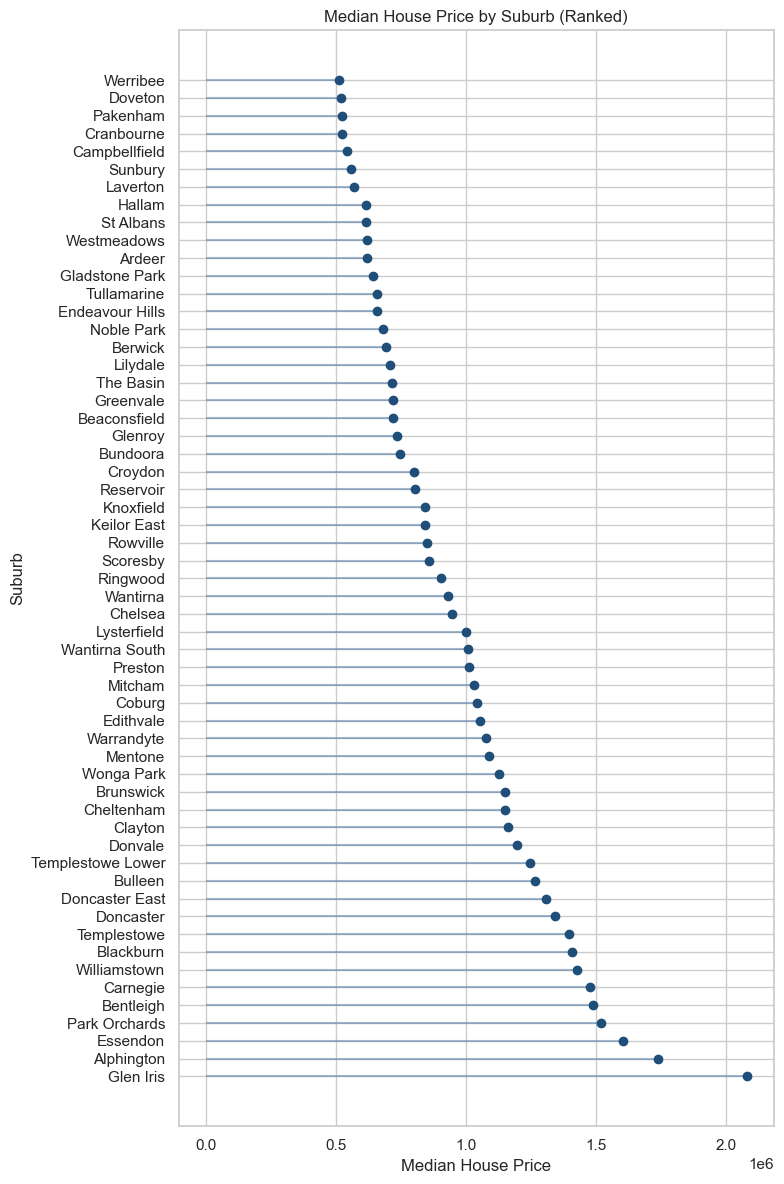

In [57]:
# Ranked median house price by suburb
suburb_median = (
    eda.groupby("Suburb", as_index=False)["HousePrice"]
    .median()
    .sort_values("HousePrice", ascending=False)
)

plt.figure(figsize=(8, 12))
plt.hlines(
    y=suburb_median["Suburb"],
    xmin=0,
    xmax=suburb_median["HousePrice"],
    color="#4C78A8",
    alpha=0.5,
 )
plt.plot(suburb_median["HousePrice"], suburb_median["Suburb"], "o", color="#1f4e79")
plt.title("Median House Price by Suburb (Ranked)")
plt.xlabel("Median House Price")
plt.ylabel("Suburb")
plt.tight_layout()
plt.show()

This ranked lollipop chart compares the median house price of each suburb across 2015-2024. It shows which suburbs have higher or lower baseline price levels before we compare adjacent and faraway groups. That matters for the research question because faster growth along the Upfield line is easier to interpret if we first understand the starting price differences across suburbs.

**Box & Whisker plot (adjacent and faraway suburbs with their median house prices)**

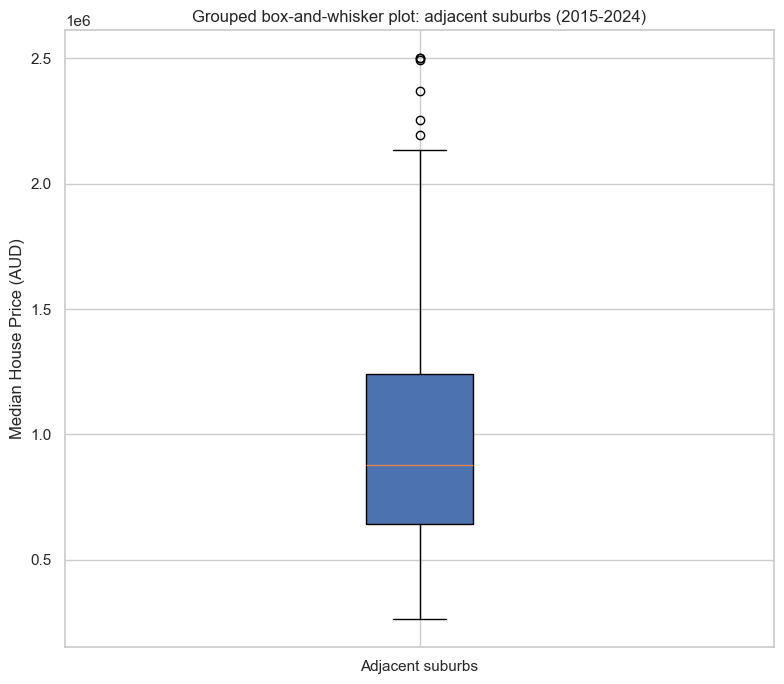

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root reliably whether or not earlier cells were run.
if "project_root" in globals():
    root = Path(project_root)
else:
    root = Path.cwd()

adjacent_path = root / "data" / "clean" / "adjacent_suburbs_house_prices_2015_2024.csv"
adjacent_df = pd.read_csv(adjacent_path)

year_cols = [str(y) for y in range(2015, 2025)]

# Stack all adjacent-suburb yearly median prices into one grouped distribution.
adjacent_values = (
    adjacent_df[year_cols]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy()
    .flatten()
)
adjacent_values = pd.Series(adjacent_values).dropna().values

fig, ax = plt.subplots(figsize=(8, 7))
ax.boxplot([adjacent_values], tick_labels=["Adjacent suburbs"], showfliers=True, patch_artist=True)
ax.set_ylabel("Median House Price (AUD)")
ax.set_title("Grouped box-and-whisker plot: adjacent suburbs (2015-2024)")
plt.tight_layout()
plt.show()

The box-and-whisker plot summarizes the distribution of yearly median house prices for adjacent suburbs over 2015-2024. It shows the level and spread of prices in suburbs closest to the Upfield line. This is directly relevant to the research question because it gives the price profile for the group that may be most affected by level crossing removals and related transport improvements.

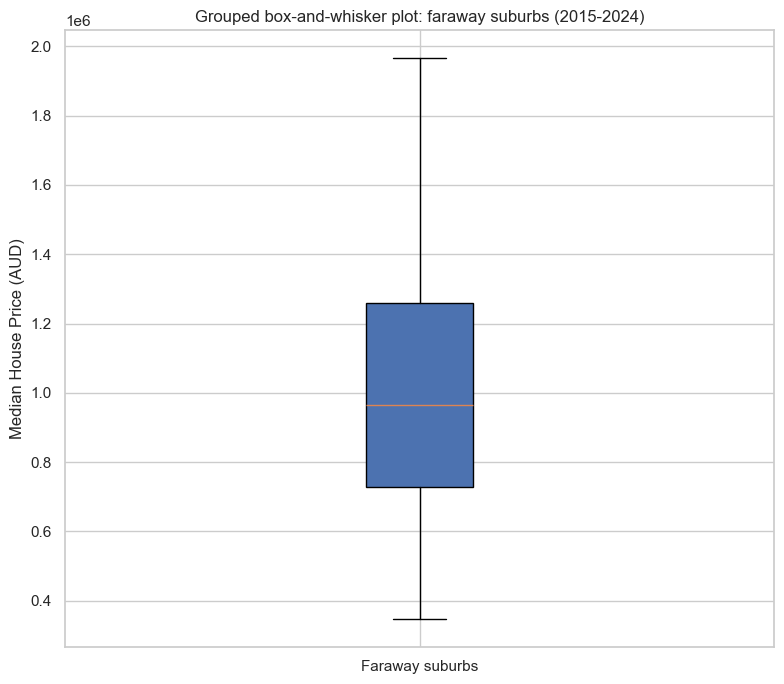

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root reliably whether or not earlier cells were run.
if "project_root" in globals():
    root = Path(project_root)
else:
    root = Path.cwd()

faraway_path = root / "data" / "clean" / "faraway_suburbs_house_prices_2015_2024.csv"
faraway_df = pd.read_csv(faraway_path)

year_cols = [str(y) for y in range(2015, 2025)]

# Stack all faraway-suburb yearly median prices into one grouped distribution.
faraway_values = (
    faraway_df[year_cols]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy()
    .flatten()
)
faraway_values = pd.Series(faraway_values).dropna().values

fig, ax = plt.subplots(figsize=(8, 7))
ax.boxplot([faraway_values], tick_labels=["Faraway suburbs"], showfliers=True, patch_artist=True)
ax.set_ylabel("Median House Price (AUD)")
ax.set_title("Grouped box-and-whisker plot: faraway suburbs (2015-2024)")
plt.tight_layout()
plt.show()

This box-and-whisker plot summarizes the distribution of yearly median house prices for faraway suburbs over 2015-2024. It provides the comparison group for suburbs less likely to be affected by the Upfield line works. Comparing this with the adjacent-group boxplot helps show whether the price pattern near the line is unusually high, low, or more volatile.

**Population density of suburbs from 2015 to 2024**

In [60]:
from pathlib import Path
import re
import pandas as pd

# -----------------------------
# 1) Suburb list (ordered)
# -----------------------------
BASE_SUBURBS = [
    "Chelsea", "Laverton", "Ringwood", "Mentone", "Preston", "Blackburn",
    "Beaconsfield", "Essendon", "Glen Iris", "Cranbourne", "Campbellfield",
    "Pakenham", "Lilydale", "Bentleigh", "Clayton", "Noble Park",
    "Cheltenham", "Werribee", "Berwick", "Croydon", "Edithvale",
    "Williamstown", "Ardeer", "St Albans", "Sunbury", "Glenroy",
    "Alphington", "Carnegie", "Hallam", "Mitcham", "Reservoir",
    "Coburg", "Brunswick", "Bundoora"
]

NEW_SUBURBS = [
    "Doncaster", "Doncaster East", "Donvale", "Templestowe", "Templestowe Lower",
    "Warrandyte", "Wonga Park", "Park Orchards", "Bulleen", "Rowville",
    "Lysterfield", "Scoresby", "Knoxfield", "Wantirna", "Wantirna South",
    "The Basin", "Endeavour Hills", "Doveton", "Greenvale", "Gladstone Park",
    "Westmeadows", "Tullamarine", "Keilor East"
]

def unique_in_order(items):
    seen, out = set(), []
    for x in items:
        x = str(x).strip()
        if x and x not in seen:
            seen.add(x)
            out.append(x)
    return out

SUBURBS = unique_in_order(BASE_SUBURBS + NEW_SUBURBS)

# -----------------------------
# 2) Explicit SA2 mapping
# -----------------------------
SA2_MAP = {
    "Chelsea": ["Chelsea - Bonbeach"],
    "Cheltenham": ["Highett (East) - Cheltenham", "Highett (West) - Cheltenham"],

    "Doncaster East": ["Doncaster East - North", "Doncaster East - South"],
    "Donvale": ["Donvale - Park Orchards"],
    "Park Orchards": ["Donvale - Park Orchards"],

    "Warrandyte": ["Warrandyte - Wonga Park"],
    "Wonga Park": ["Warrandyte - Wonga Park"],

    "Rowville": ["Rowville - Central", "Rowville - North", "Rowville - South"],
    "Scoresby": ["Knoxfield - Scoresby"],
    "Knoxfield": ["Knoxfield - Scoresby"],

    "Endeavour Hills": ["Endeavour Hills - North", "Endeavour Hills - South"],

    "Greenvale": ["Greenvale - Bulla"],
    "Gladstone Park": ["Gladstone Park - Westmeadows"],
    "Westmeadows": ["Gladstone Park - Westmeadows"],
}

YEARS = list(range(2015, 2025))

# -----------------------------
# 3) Paths
# -----------------------------
project_root = Path.cwd()
if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

pop_path = project_root / "data" / "raw" / "abs_population.xlsx"
sa2_area_path = project_root / "data" / "raw" / "SA2_2021_AUST.xlsx"

out_long = project_root / "data" / "clean" / "requested_suburbs_density_2015_2024_long.csv"
out_wide = project_root / "data" / "clean" / "requested_suburbs_density_2015_2024.csv"

# -----------------------------
# 4) Load population
# -----------------------------
hdr = pd.read_excel(pop_path, sheet_name="Table 1", header=None, nrows=6)
colnames = hdr.iloc[5, :10].tolist() + hdr.iloc[4, 10:].tolist()

pop = pd.read_excel(pop_path, sheet_name="Table 1", header=None, skiprows=6)
pop.columns = colnames

pop["S/T name"] = pop["S/T name"].astype(str).str.strip()
pop = pop[pop["S/T name"].eq("Victoria")].copy()  # IMPORTANT: keep only VIC

pop["SA2 code"] = pd.to_numeric(pop["SA2 code"], errors="coerce").astype("Int64")
pop["SA2 name"] = pop["SA2 name"].astype(str).str.strip()

for y in YEARS:
    pop[y] = pd.to_numeric(pop[y], errors="coerce")

# -----------------------------
# 5) Load SA2 areas
# -----------------------------
sa2 = pd.read_excel(
    sa2_area_path,
    usecols=["SA2_CODE_2021", "SA2_NAME_2021", "AREA_ALBERS_SQKM", "STATE_NAME_2021"]
)
sa2["STATE_NAME_2021"] = sa2["STATE_NAME_2021"].astype(str).str.strip()
sa2 = sa2[sa2["STATE_NAME_2021"].eq("Victoria")].copy()

sa2["SA2_CODE_2021"] = pd.to_numeric(sa2["SA2_CODE_2021"], errors="coerce").astype("Int64")
sa2["SA2_NAME_2021"] = sa2["SA2_NAME_2021"].astype(str).str.strip()
sa2 = sa2.rename(columns={"AREA_ALBERS_SQKM": "sa2_area_km2"})

# join area to population by SA2 code
pop = pop.merge(
    sa2[["SA2_CODE_2021", "sa2_area_km2"]],
    left_on="SA2 code",
    right_on="SA2_CODE_2021",
    how="left"
)

sa2_names_all = set(pop["SA2 name"].dropna().unique())

# -----------------------------
# 6) Robust SA2 resolver
# -----------------------------
def resolve_sa2_names(suburb):
    # 1) explicit mapping first
    if suburb in SA2_MAP:
        return SA2_MAP[suburb]

    # 2) exact match
    if suburb in sa2_names_all:
        return [suburb]

    # 3) ""<suburb> - ..."" prefix match
    starts_with_dash = sorted(
        [n for n in sa2_names_all if n.lower().startswith(suburb.lower() + " -")]
    )
    if len(starts_with_dash) >= 1:
        return starts_with_dash

    # 4) strict word-boundary match
    pattern = re.compile(rf"\b{re.escape(suburb)}\b", flags=re.IGNORECASE)
    matches = sorted([n for n in sa2_names_all if pattern.search(n)])

    if len(matches) == 0:
        raise ValueError(f"No SA2 match found for suburb: {suburb}")

    # If multiple in VIC, aggregate all
    return matches

# -----------------------------
# 7) Build density table
# -----------------------------
rows = []

for suburb in SUBURBS:
    sa2_names = resolve_sa2_names(suburb)
    sub = pop[pop["SA2 name"].isin(sa2_names)].copy()

    if sub.empty:
        continue

    # area: sum unique SA2 areas used for this suburb
    area_total = (
        sub[["SA2 code", "sa2_area_km2"]]
        .drop_duplicates()
        ["sa2_area_km2"]
        .sum(min_count=1)
    )

    if pd.isna(area_total) or area_total == 0:
        raise ValueError(f"Missing or zero area for suburb: {suburb} | SA2: {sa2_names}")

    for y in YEARS:
        pop_total = sub[y].sum(min_count=1)
        dens = pop_total / area_total if pd.notna(pop_total) else pd.NA

        rows.append({
            "Suburb": suburb,
            "Year": y,
            "Population": pop_total,
            "Area_km2": area_total,
            "Density": dens,
            "SA2_components": " | ".join(sa2_names),
        })

long_df = pd.DataFrame(rows)

# keep requested order
long_df["Suburb"] = pd.Categorical(long_df["Suburb"], categories=SUBURBS, ordered=True)
long_df = long_df.sort_values(["Suburb", "Year"]).reset_index(drop=True)

# -----------------------------
# 8) Save long
# -----------------------------
long_df.to_csv(out_long, index=False)

# -----------------------------
# 9) Save wide + numbering
# -----------------------------
wide = (
    long_df.pivot(index="Suburb", columns="Year", values="Density")
    .reindex(SUBURBS)
    .reset_index()
)
wide.columns = ["Suburb"] + [str(y) for y in YEARS]
wide.insert(0, "No.", range(1, len(wide) + 1))

wide.to_csv(out_wide, index=False)

print(f"Saved long: {out_long}")
print(f"Saved wide: {out_wide}")
print(f"Suburbs in wide: {wide['Suburb'].nunique()}")

pd.set_option("display.max_rows", None)
display(wide)

Saved long: c:\Users\samantha\Desktop\uni ૮₍•᷄ ࡇ•᷅₎ა\Y3S1\ECC3479\ECC3479-project\ecc3479-project\ECC3479-project (data + GitHub repo)\data\clean\requested_suburbs_density_2015_2024_long.csv
Saved wide: c:\Users\samantha\Desktop\uni ૮₍•᷄ ࡇ•᷅₎ა\Y3S1\ECC3479\ECC3479-project\ecc3479-project\ECC3479-project (data + GitHub repo)\data\clean\requested_suburbs_density_2015_2024.csv
Suburbs in wide: 57


,No.,Suburb,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,Chelsea,2654.619214,2735.201918,2776.507468,2804.720634,2824.451411,2844.550987,2824.451411,2828.508206,2870.735755,2921.261294
1,2,Laverton,374.644304,421.890664,461.000400,489.950596,516.922828,538.185938,523.396164,532.207093,555.583027,569.653542
2,3,Ringwood,1781.343020,1809.293174,1846.627314,1867.110640,1904.646587,1933.101256,1908.985420,1913.324252,1947.126785,1976.994097
3,4,Mentone,2995.955056,3077.528090,3097.528090,3104.044944,3119.775281,3113.707865,2989.438202,2999.325843,3079.101124,3133.707865
4,5,Preston,2936.200679,3010.447603,3047.129119,3064.099844,3080.628624,3095.743176,2989.410974,2986.317353,3097.069014,3172.023052
5,6,Blackburn,2538.454389,2589.688183,2625.819044,2642.199916,2664.041080,2675.774897,2597.239649,2590.617594,2660.091082,2720.270459
6,7,Beaconsfield,351.395326,405.891075,465.439410,533.619246,609.287736,673.106709,720.775452,774.429103,809.676905,851.300590
7,8,Essendon,3349.464029,3452.156543,3518.836339,3548.096672,3572.574065,3590.861773,3464.535914,3447.092254,3549.503418,3622.654250
8,9,Glen Iris,2993.041070,3011.796876,3042.296973,3053.340111,3069.466599,3045.627443,2980.946204,2956.230609,3015.127347,3065.960841
9,10,Cranbourne,1578.874645,1603.439011,1627.926614,1643.816688,1651.646580,1663.698472,1656.636217,1656.405926,1687.495202,1724.725570


**Box and whisker plot for population density across all suburbs**

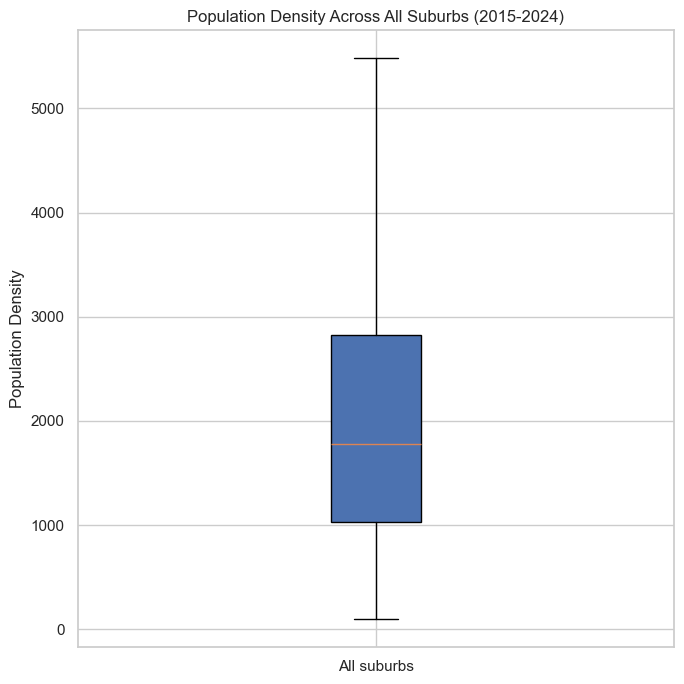

In [61]:
density_cols = [col for col in wide.columns if col not in ["No.", "Suburb"]]
density_values = wide[density_cols].apply(pd.to_numeric, errors="coerce").to_numpy().ravel()
density_values = density_values[~pd.isna(density_values)]

plt.figure(figsize=(7, 7))
plt.boxplot(
    [density_values],
    tick_labels=["All suburbs"],
    vert=True,
    showfliers=False,
    patch_artist=True,
)
plt.title("Population Density Across All Suburbs (2015-2024)")
plt.ylabel("Population Density")
plt.tight_layout()
plt.show()

This boxplot combines all suburb-year density observations (2015-2024) into a single distribution. It shows the overall range of density across the study area, which helps us understand how much variation there is in the places being compared. That matters because population density may help explain why house prices respond differently in adjacent suburbs versus faraway suburbs.

**Time series for overall house price trend by suburb group**

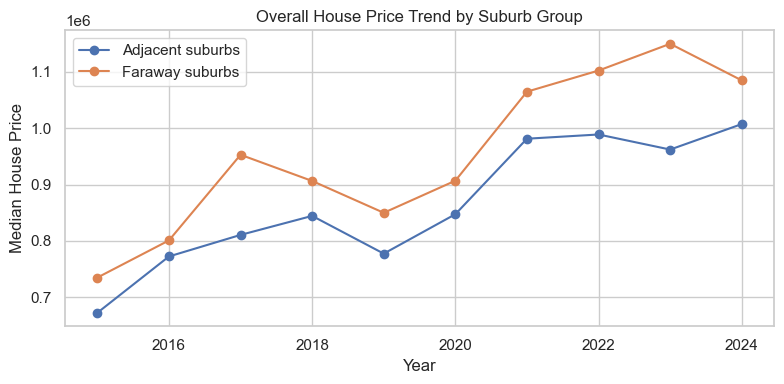

In [62]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

YEARS = list(range(2015, 2025))
YEAR_STR = [str(y) for y in YEARS]

project_root = Path.cwd()
if not (project_root / "data" / "clean").exists():
    project_root = project_root.parent

clean = project_root / "data" / "clean"

def melt_wide(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    out = df.melt(id_vars=["Suburb"], value_vars=YEAR_STR, var_name="Year", value_name=value_name)
    out["Year"] = pd.to_numeric(out["Year"], errors="coerce").astype(int)
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    return out

def build_lxrp_table() -> pd.DataFrame:
    suburbs = [
        ("Chelsea", 4), ("Laverton", 3), ("Ringwood", 2), ("Mentone", 2), ("Preston", 1),
        ("Blackburn", 2), ("Beaconsfield", 2), ("Essendon", 1), ("Glen Iris", 1),
        ("Cranbourne", 3), ("Campbellfield", 3), ("Pakenham", 3), ("Lilydale", 2),
        ("Bentleigh", 1), ("Clayton", 2), ("Noble Park", 2), ("Cheltenham", 2),
        ("Werribee", 3), ("Berwick", 3), ("Croydon", 0), ("Edithvale", 2),
        ("Williamstown", 1), ("Ardeer", 1), ("St Albans", 1), ("Sunbury", 2),
        ("Glenroy", 0), ("Alphington", 1), ("Carnegie", 1), ("Hallam", 3),
        ("Mitcham", 2), ("Reservoir", 0), ("Coburg", 0), ("Brunswick", 0), ("Bundoora", 4),
        ("Doncaster", 10), ("Doncaster East", 12), ("Donvale", 9), ("Templestowe", 8),
        ("Templestowe Lower", 6), ("Warrandyte", 12), ("Wonga Park", 15), ("Park Orchards", 9),
        ("Bulleen", 10), ("Rowville", 10), ("Lysterfield", 11), ("Scoresby", 9),
        ("Knoxfield", 9), ("Wantirna", 6), ("Wantirna South", 7), ("The Basin", 7),
        ("Endeavour Hills", 6), ("Doveton", 4), ("Greenvale", 7), ("Gladstone Park", 6),
        ("Westmeadows", 3), ("Tullamarine", 6), ("Keilor East", 4),
    ]
    return pd.DataFrame(suburbs, columns=["Suburb", "nearest_lxrp_site"]).drop_duplicates("Suburb")

density_wide = pd.read_csv(clean / "requested_suburbs_density_2015_2024.csv").drop(columns=["No."], errors="ignore")
price_wide = pd.read_csv(clean / "closest_lxrp_site_house_prices_2015_2024.csv")
income = pd.read_csv(clean / "annual_household_income_table.csv")
lxrp = build_lxrp_table()

adjacent_suburbs = set(
    pd.read_csv(clean / "adjacent_suburbs_house_prices_2015_2024.csv")["Suburb"].astype(str).str.strip()
)
faraway_suburbs = set(
    pd.read_csv(clean / "faraway_suburbs_house_prices_2015_2024.csv")["Suburb"].astype(str).str.strip()
)

density_long = melt_wide(density_wide, "Density")
price_long = melt_wide(price_wide, "HousePrice")

panel = (
    price_long
    .merge(density_long, on=["Suburb", "Year"], how="inner")
    .merge(lxrp, on="Suburb", how="left")
    .merge(income.rename(columns={"Annual total household income ($/year)": "AnnualIncome"}), on="Suburb", how="left")
)

panel["Group"] = "Unclassified"
panel.loc[panel["Suburb"].isin(adjacent_suburbs), "Group"] = "Adjacent"
panel.loc[panel["Suburb"].isin(faraway_suburbs), "Group"] = "Faraway"
panel = panel[panel["Group"].isin(["Adjacent", "Faraway"])].copy()

panel["log_HousePrice"] = np.log(panel["HousePrice"])
panel["log_Density"] = np.log(panel["Density"].clip(lower=1e-9))

grouped_yearly = panel.groupby(["Year", "Group"], as_index=False).agg(
    HousePriceMedian=("HousePrice", "median"),
    DensityMedian=("Density", "median"),
)

plt.figure(figsize=(8, 4))
for grp in ["Adjacent", "Faraway"]:
    tmp = grouped_yearly[grouped_yearly["Group"] == grp]
    plt.plot(tmp["Year"], tmp["HousePriceMedian"], marker="o", label=f"{grp} suburbs")
plt.title("Overall House Price Trend by Suburb Group")
plt.xlabel("Year")
plt.ylabel("Median House Price")
plt.legend()
plt.tight_layout()
plt.show()

This graph shows a two time-series lines compare yearly median house prices for adjacent versus faraway suburbs.

This is the most direct EDA check for the research question because it shows whether adjacent suburbs appear to experience faster house-price growth than suburbs farther from the Upfield line. If the adjacent line rises more steeply or stays consistently above the faraway line, that would support the idea that proximity to the transport changes is associated with stronger price growth.

**Overall density trend by suburb group**

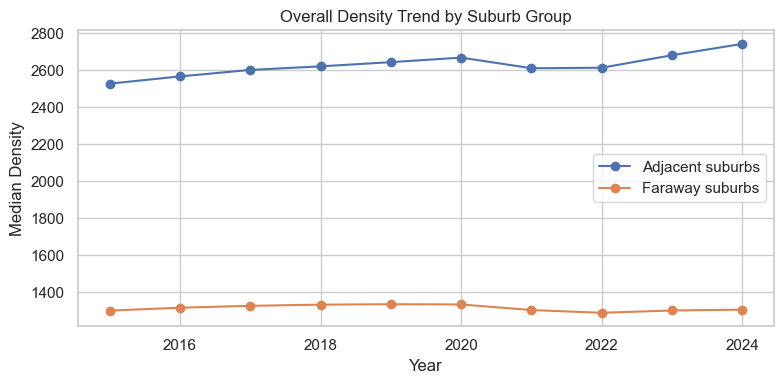

In [63]:

plt.figure(figsize=(8, 4))
for grp in ["Adjacent", "Faraway"]:
    tmp = grouped_yearly[grouped_yearly["Group"] == grp]
    plt.plot(tmp["Year"], tmp["DensityMedian"], marker="o", label=f"{grp} suburbs")
plt.title("Overall Density Trend by Suburb Group")
plt.xlabel("Year")
plt.ylabel("Median Density")
plt.legend()
plt.tight_layout()
plt.show()

This graph shows a two time-series lines compare yearly median population density for adjacent versus faraway suburbs.

This helps check whether the two suburb groups differ in a way that could be related to the research question rather than to house prices alone. If adjacent suburbs are denser or become denser differently over time, that matters because density can help explain why prices may move differently near the Upfield corridor.

**Scatterplot showing house price vs population density**

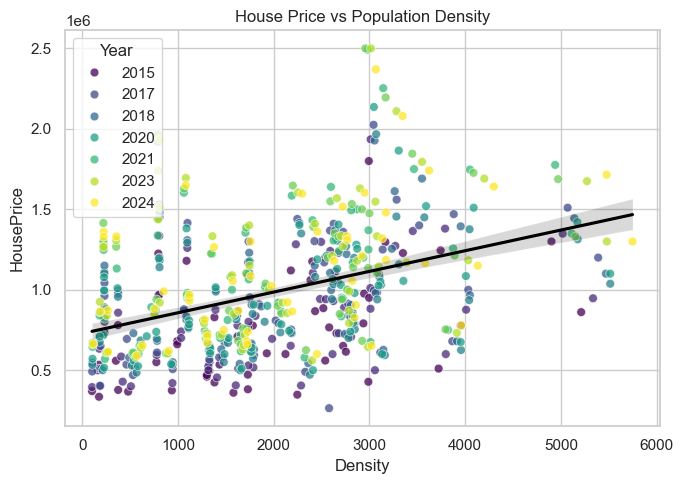

In [64]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=panel, x="Density", y="HousePrice", hue="Year", palette="viridis", s=40, alpha=0.75)
sns.regplot(data=panel, x="Density", y="HousePrice", scatter=False, color="black")
plt.title("House Price vs Population Density")
plt.tight_layout()
plt.show()

Each point is a suburb-year observation with density on the x-axis and house price on the y-axis, colored by year, plus a fitted trend line.

This checks whether population density is linked to house prices in a way that could help explain differences between adjacent and faraway suburbs. It does not answer the research question by itself, but it shows whether density is a useful supporting variable when studying price growth around the Upfield line.

**Correlation heatmap**

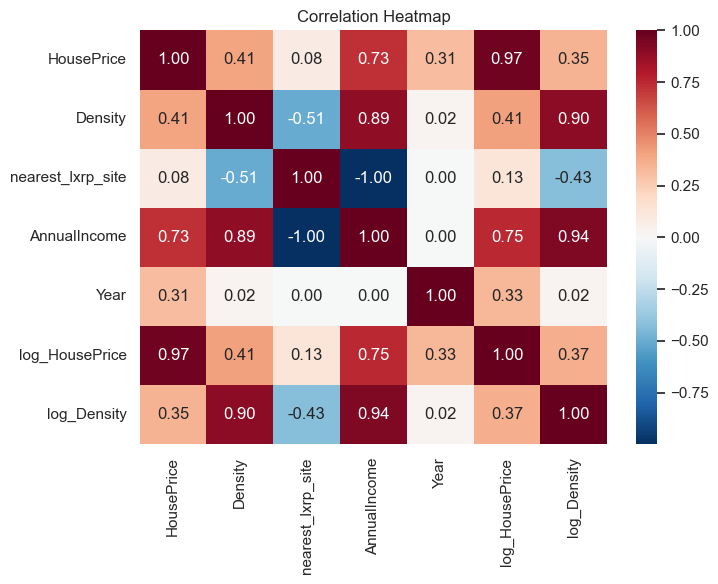

In [65]:
corr_cols = ["HousePrice", "Density", "nearest_lxrp_site", "AnnualIncome", "Year", "log_HousePrice", "log_Density"]
corr = panel[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The heatmap reports pairwise linear correlations among house price, density, LXRP proximity, income, year and log-transformed variables.

A Pearson-style correlation is useful here only as a supporting summary, not as the main answer to the research question. Because suburb group is categorical and the key issue is whether adjacent suburbs grow differently over time, the heatmap mainly helps judge whether density, year, and price move together strongly enough to justify using them in the later comparison.

**Between-suburb vs within-suburb relationship**

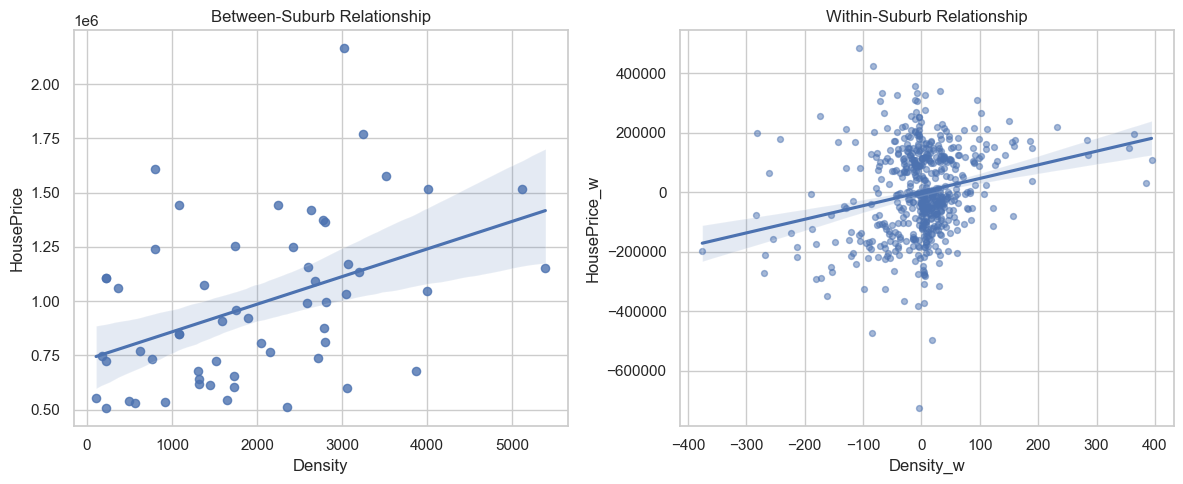

In [66]:
between = panel.groupby("Suburb", as_index=False)[["HousePrice", "Density"]].mean()

within = panel.copy()
within["HousePrice_w"] = within["HousePrice"] - within.groupby("Suburb")["HousePrice"].transform("mean")
within["Density_w"] = within["Density"] - within.groupby("Suburb")["Density"].transform("mean")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=between, x="Density", y="HousePrice", ax=axs[0], scatter_kws={"s": 35})
axs[0].set_title("Between-Suburb Relationship")

sns.regplot(data=within, x="Density_w", y="HousePrice_w", ax=axs[1], scatter_kws={"s": 18, "alpha": 0.5})
axs[1].set_title("Within-Suburb Relationship")

plt.tight_layout()
plt.show()

The left panel uses suburb-level averages (between variation), while the right panel de-means each suburb to isolate within-suburb variation over time.

This is important for the research question because it shows whether the price-density relationship is really about differences between adjacent and faraway suburbs, or about changes within the same suburb over time. If the two slopes differ, then simple pooled comparisons could hide the pattern we care about near the Upfield line.

**OLS diagnostics: residuals vs fitted and Q-Q Plot**

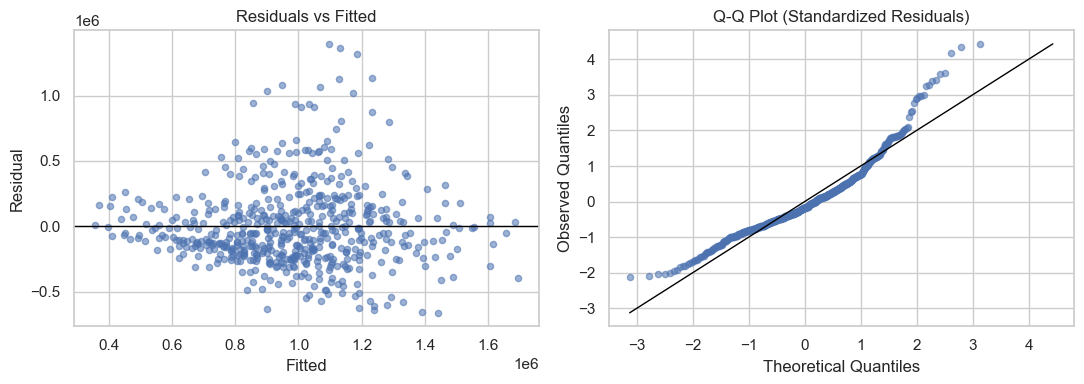

In [67]:
ols = panel[["HousePrice", "Density", "nearest_lxrp_site", "Year"]].dropna().copy()

X = np.column_stack([
    np.ones(len(ols)),
    ols["Density"].to_numpy(),
    ols["nearest_lxrp_site"].to_numpy(),
    ols["Year"].to_numpy(),
])
y = ols["HousePrice"].to_numpy()

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
fitted = X @ beta
resid = y - fitted

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].scatter(fitted, resid, alpha=0.55, s=20)
axs[0].axhline(0, color="black", lw=1)
axs[0].set_title("Residuals vs Fitted")
axs[0].set_xlabel("Fitted")
axs[0].set_ylabel("Residual")

n = len(resid)
obs = np.sort((resid - resid.mean()) / (resid.std(ddof=1) + 1e-12))
probs = (np.arange(1, n + 1) - 0.5) / n
theor = np.sqrt(2) * np.vectorize(lambda x: np.sign(x) * np.sqrt(np.sqrt((2 / (np.pi * 0.147) + np.log(1 - x * x + 1e-12) / 2) ** 2 - np.log(1 - x * x + 1e-12) / 0.147) - (2 / (np.pi * 0.147) + np.log(1 - x * x + 1e-12) / 2)))(2 * probs - 1)

mn, mx = min(theor.min(), obs.min()), max(theor.max(), obs.max())
axs[1].scatter(theor, obs, alpha=0.55, s=20)
axs[1].plot([mn, mx], [mn, mx], color="black", lw=1)
axs[1].set_title("Q-Q Plot (Standardized Residuals)")
axs[1].set_xlabel("Theoretical Quantiles")
axs[1].set_ylabel("Observed Quantiles")

plt.tight_layout()
plt.show()

The residuals-vs-fitted plot checks nonlinearity and heteroskedasticity, while the Q-Q plot checks whether standardized residuals follow approximate normality.

These diagnostics tell us whether a simple linear relationship is too crude for the research question. If the assumptions are weak, then the apparent adjacent-vs-faraway difference may need a more careful model before we claim anything about faster price growth along the Upfield line.